In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

In [4]:
#df = pd.read_csv("C:/Users/ABhinav/Desktop/Python/Loan_Prediction/Train_File.csv")
#df = pd.read_csv("/Users/abhinavmohanty/Documents/Python/Python - Exploration/Loan_Prediction/Train_File.csv")
df = pd.read_csv("../DataSets/loan_prediction_train.csv")
print(df.head(10))
print("\n", df.describe())
print("\n", df['Property_Area'].value_counts())
#print(df['ApplicantIncome'].value_counts())
    #df['ApplicantIncome'].hist()
#df['ApplicantIncome'].hist(bins=50)
    #plt.ylabel('Y')
    #plt.xlabel('X')
#plt.show()
#df.boxplot(column='ApplicantIncome')
#plt.show()
#df.boxplot(column='ApplicantIncome',by='Education')
#plt.show()
#df['LoanAmount'].hist(bins=50)
#plt.show()
#df.boxplot(column='LoanAmount')
#plt.show()

    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   
5  LP001011   Male     Yes          2      Graduate           Yes   
6  LP001013   Male     Yes          0  Not Graduate            No   
7  LP001014   Male     Yes         3+      Graduate            No   
8  LP001018   Male     Yes          2      Graduate            No   
9  LP001020   Male     Yes          1      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000         

In [6]:
print('Frequency Table for Credit History:')
temp1=df['Credit_History'].value_counts(ascending=True)
print(temp1)
print('\nProbability of getting loan for Credit History class:')
temp2=df.pivot_table(values='Loan_Status',index=['Credit_History'],aggfunc=lambda x: x.map({'Y':1,'N':0}).mean())
print(temp2)
temp3=pd.crosstab(df['Credit_History'],df['Loan_Status'])
print("\n",temp3)

Frequency Table for Credit History:
0.0     89
1.0    475
Name: Credit_History, dtype: int64

Probability of getting loan for Credit History class:
                Loan_Status
Credit_History             
0.0                0.078652
1.0                0.795789

 Loan_Status      N    Y
Credit_History         
0.0             82    7
1.0             97  378


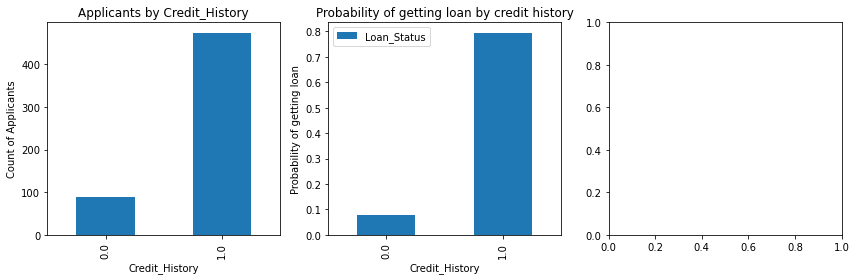

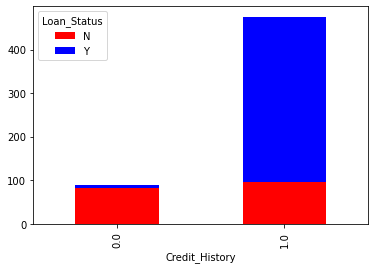

In [7]:
fig, axs = plt.subplots(nrows = 1, ncols=3, figsize=(12,4))
#fig, axs = plt.subplots(nrows = 3, ncols=1, figsize = (8,12))
temp1.plot(kind='bar', title='Applicants by Credit_History', ax=axs[0])             
axs[0].set_xlabel('Credit_History')
axs[0].set_ylabel('Count of Applicants')
temp2.plot(kind = 'bar', title='Probability of getting loan by credit history', ax=axs[1])
axs[1].set_xlabel('Credit_History')
axs[1].set_ylabel('Probability of getting loan')
temp3.plot(kind='bar',stacked=True,color=['red','blue'],grid=False)
fig.tight_layout()
plt.show()
plt.clf()
plt.close()

In [9]:
print(df.apply(lambda x: sum(x.isnull()),axis=0))
print("\n",df['Self_Employed'].value_counts())
df['Self_Employed'].fillna('No',inplace=True)
print("\n",df['Self_Employed'].value_counts())
#df['LoanAmount'].fillna(df['LoanAmount'].mean(), inplace=True)
table = df.pivot_table(values='LoanAmount', index='Self_Employed' ,columns='Education', aggfunc=np.median)

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed         0
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

 No     532
Yes     82
Name: Self_Employed, dtype: int64

 No     532
Yes     82
Name: Self_Employed, dtype: int64


In [11]:
def fage(x):
    return table.loc[x['Self_Employed'],x['Education']]

In [17]:
#df['LoanAmount'].fillna(df[df['LoanAmount'].isnull()].apply(fage, axis=1), inplace=True)
df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)
df['Married'].fillna(df['Married'].mode()[0], inplace=True)
df['Dependents'].fillna(df['Dependents'].mode()[0], inplace=True)
df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0], inplace=True)
df['Credit_History'].fillna(df['Credit_History'].mode()[0], inplace=True)
print(df.apply(lambda x: sum(x.isnull()),axis=0))

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


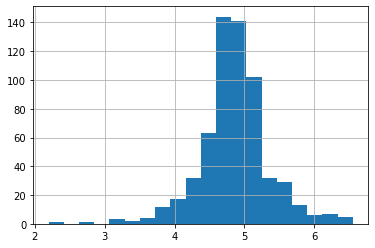

In [18]:
df['LoanAmount_log'] = np.log(df['LoanAmount'])
df['LoanAmount_log'].hist(bins=20)
plt.show()

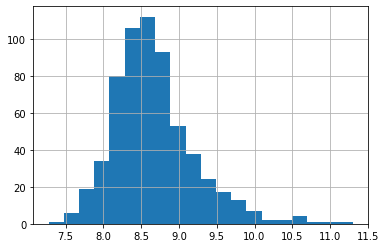

In [20]:
df['TotalIncome'] = df['ApplicantIncome'] + df['CoapplicantIncome']
df['TotalIncome_log'] = np.log(df['TotalIncome'])
df['TotalIncome_log'].hist(bins=20)
plt.show()

In [23]:
print(df.dtypes)
var_mod = ['Gender','Married','Dependents','Education','Self_Employed','Property_Area','Loan_Status']
le = LabelEncoder()
for i in var_mod:
    df[i] = le.fit_transform(df[i])
print("\n",df.dtypes)

Loan_ID               object
Gender                 int64
Married                int64
Dependents             int64
Education              int64
Self_Employed          int64
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area          int64
Loan_Status            int64
LoanAmount_log       float64
TotalIncome          float64
TotalIncome_log      float64
dtype: object

 Loan_ID               object
Gender                 int64
Married                int64
Dependents             int64
Education              int64
Self_Employed          int64
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area          int64
Loan_Status            int64
LoanAmount_log       float64
TotalIncome          float64
TotalIncome_log      float64
dtype: object


In [24]:
#ABContinue
from sklearn.linear_model import LogisticRegression
#from sklearn.linear_model import lbfgs
from sklearn.model_selection import KFold
from sklearn import metrics
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, export_graphviz

In [29]:
def classification_model(model, data, predictors, outcome):
    model.fit(data[predictors],data[outcome])
    predictions = model.predict(data[predictors])
    accuracy = metrics.accuracy_score(predictions,data[outcome])
    print ("Accuracy : %s" % "{0:.3%}".format(accuracy))
    #kf = KFold(5, shuffle=False)
    #error = []
    #for train, test in kf.split(data.shape[0]):
     #   train_predictors = (data[predictors].iloc[train,:])
      #  train_target = data[outcome].iloc[train]
       # model.fit(train_predictors, train_target)
        #error.append(model.score(data[predictors].iloc[test,:], data[outcome].iloc[test]))
    #print ("Cross-Validation Score : %s" % "{0:.3%}".format(np.mean(error)))
    model.fit(data[predictors],data[outcome])

In [30]:
outcome_var = 'Loan_Status'
model = LogisticRegression()
#model = lbfgs()
predictor_var = ['Credit_History']
classification_model(model, df, predictor_var, outcome_var)
predictor_var = ['Credit_History','Education','Married','Self_Employed','Property_Area']
classification_model(model, df,predictor_var,outcome_var)

model = DecisionTreeClassifier()
predictor_var = ['Credit_History','Gender','Married','Education']
classification_model(model, df,predictor_var,outcome_var)
predictor_var = ['Credit_History','Loan_Amount_Term','LoanAmount_log']
classification_model(model, df,predictor_var,outcome_var)

model = RandomForestClassifier(n_estimators=100)
predictor_var = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'LoanAmount_log','TotalIncome_log']
classification_model(model, df,predictor_var,outcome_var)
featimp = pd.Series(model.feature_importances_, index=predictor_var).sort_values(ascending=False)
print (featimp)
model = RandomForestClassifier(n_estimators=25, min_samples_split=25, max_depth=7, max_features=1)
predictor_var = ['TotalIncome_log','LoanAmount_log','Credit_History','Dependents','Property_Area']
classification_model(model, df,predictor_var,outcome_var)

Accuracy : 80.945%
Accuracy : 80.945%
Accuracy : 80.945%
Accuracy : 88.925%
Accuracy : 100.000%
Credit_History      0.272171
TotalIncome_log     0.268181
LoanAmount_log      0.222234
Property_Area       0.054021
Dependents          0.050352
Loan_Amount_Term    0.043402
Married             0.024139
Gender              0.023028
Education           0.021969
Self_Employed       0.020502
dtype: float64
Accuracy : 83.388%
